# Train & đánh giá — RetinaNet

- Checkpoint riêng: `checkpoints/retinanet/` (không ghi đè lẫn model khác)
- Data augmentation (flip + color jitter) để công bằng với YOLO
- LR warmup epoch đầu, learning curve theo epoch, best.pth + early stopping
- Đánh giá cuối trên **tập test (19.200 ảnh)** bằng best.pth
- Ghi kết quả vào `comparison_results.json` theo schema chung cho notebook so sánh

## 1. Mount Drive & giải nén gold dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

DRIVE_ZIP_PATH = '/content/drive/MyDrive/UIT/graduate_project/rpc_dataset/gold_dataset_detector_3models.zip'
EXTRACT_DIR = '/content/gold_dataset'
CHECKPOINT_DIR = '/content/drive/MyDrive/UIT/graduate_project/checkpoints/retinanet'
RESULTS_JSON = '/content/drive/MyDrive/UIT/graduate_project/checkpoints/comparison_results.json'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("Đang giải nén gold dataset về SSD Colab...")
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print("Giải nén xong.")
else:
    print("Đã tồn tại, bỏ qua giải nén.")


Mounted at /content/drive
Đang giải nén gold dataset về SSD Colab...
Giải nén xong.


## 2. Import, seed & cấu hình

In [ ]:
import json, time, random, math
import numpy as np
import torch
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models import ResNet50_Weights
from torchvision.transforms import functional as tvF
from torchvision.ops import box_iou
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from PIL import Image
import torchvision.transforms as T

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Cấu hình đường dẫn
IMG_TRAIN = '/content/gold_dataset/images/train'
IMG_VAL   = '/content/gold_dataset/images/val'
IMG_TEST  = '/content/gold_dataset/images/test'
ANN_TRAIN = '/content/gold_dataset/coco_annotations/instances_train.json'
ANN_VAL   = '/content/gold_dataset/coco_annotations/instances_val.json'
ANN_TEST  = '/content/gold_dataset/coco_annotations/instances_test.json'

NUM_CLASSES = 2 # 0 = background, 1 = product
NUM_EPOCHS = 40  # ước lượng epoch tối đa
BATCH_SIZE = 54
LEARNING_RATE = 0.045
EARLY_STOP_PATIENCE = 6 # dừng nếu 6 epoch liên tiếp val mAP không cải thiện
MONITOR_SUBSET = 1500 # số ảnh val theo dõi mỗi epoch cho nhanh


Device: cuda


## 3. Dataset (train có augmentation, val/test không)

In [ ]:
class CocoDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, ann_file, train=False):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.train = train
        self.jitter = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)

    def __getitem__(self, i):
        img_id = self.ids[i]
        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        info = self.coco.loadImgs(img_id)[0]
        img = Image.open(os.path.join(self.img_dir, info['file_name'])).convert('RGB')
        W = info['width']

        boxes, labels = [], []
        for a in anns:
            x, y, w, h = a['bbox']
            if w <= 0 or h <= 0:
                continue
            boxes.append([x, y, x+w, y+h]); labels.append(a['category_id'])
        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4))
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        if self.train:
            img = self.jitter(img)
            if random.random() < 0.5:
                img = tvF.hflip(img)
                if len(boxes):
                    x1 = boxes[:,0].clone(); x2 = boxes[:,2].clone()
                    boxes[:,0] = W - x2; boxes[:,2] = W - x1

        target = {'boxes': boxes, 'labels': labels, 'image_id': torch.tensor([img_id])}
        return tvF.to_tensor(img), target

    def __len__(self):
        return len(self.ids)

def collate_fn(b): return tuple(zip(*b))

train_ds = CocoDetectionDataset(IMG_TRAIN, ANN_TRAIN, train=True)
val_ds   = CocoDetectionDataset(IMG_VAL, ANN_VAL, train=False)
test_ds  = CocoDetectionDataset(IMG_TEST, ANN_TEST, train=False)

# subset val nhỏ để theo dõi mỗi epoch
gsub = torch.Generator().manual_seed(SEED)
mon_idx = torch.randperm(len(val_ds), generator=gsub)[:MONITOR_SUBSET].tolist()
val_mon = torch.utils.data.Subset(val_ds, mon_idx)
mon_img_ids = [val_ds.ids[i] for i in mon_idx]

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_mon_loader = torch.utils.data.DataLoader(val_mon, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)

print(f"Train {len(train_ds)} | Val {len(val_ds)} (theo dõi {len(val_mon)}) | Test {len(test_ds)}")


loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.66s)
creating index...
index created!
Train 6000 | Val 4800 (theo dõi 1500) | Test 19200


## 4. Model & optimizer

In [ ]:
model = retinanet_resnet50_fpn(weights=None, weights_backbone=ResNet50_Weights.IMAGENET1K_V1, num_classes=NUM_CLASSES)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, NUM_EPOCHS//3), gamma=0.1)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


## 5. Hàm đánh giá dùng chung

In [ ]:
@torch.no_grad()
def evaluate_coco(model, loader, coco_gt, limit_ids=None):
    model.eval(); results = []
    for images, targets in loader:
        images = [im.to(device) for im in images]
        for t, o in zip(targets, model(images)):
            iid = int(t['image_id'].item())
            for box, sc, lb in zip(o['boxes'].cpu().numpy(), o['scores'].cpu().numpy(), o['labels'].cpu().numpy()):
                x1,y1,x2,y2 = box
                results.append({'image_id': iid, 'category_id': int(lb),
                                'bbox':[float(x1),float(y1),float(x2-x1),float(y2-y1)], 'score': float(sc)})
    if not results:
        return None
    ce = COCOeval(coco_gt, coco_gt.loadRes(results), iouType='bbox')
    if limit_ids is not None:
        ce.params.imgIds = limit_ids
    ce.evaluate(); ce.accumulate(); ce.summarize()
    return ce.stats

@torch.no_grad()
def compute_val_loss(model, loader):
    was = model.training; model.train(); tot, n = 0.0, 0
    for images, targets in loader:
        images = [im.to(device) for im in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]
        tot += sum(l for l in model(images, targets).values()).item(); n += 1
    if not was: model.eval()
    return tot / max(n,1)

@torch.no_grad()
def compute_pr_f1(model, loader, score_thr=0.5, iou_thr=0.5):
    model.eval(); TP=FP=FN=0
    for images, targets in loader:
        images = [im.to(device) for im in images]
        for t, o in zip(targets, model(images)):
            gt = t['boxes'].to(device); pred = o['boxes'][o['scores'] >= score_thr]
            if len(gt)==0: FP += len(pred); continue
            if len(pred)==0: FN += len(gt); continue
            ious = box_iou(pred, gt); matched=set()
            for pi in range(len(pred)):
                gi = int(ious[pi].argmax())
                if float(ious[pi,gi]) >= iou_thr and gi not in matched:
                    TP += 1; matched.add(gi)
                else:
                    FP += 1
            FN += len(gt) - len(matched)
    P = TP/(TP+FP+1e-9); R = TP/(TP+FN+1e-9); F1 = 2*P*R/(P+R+1e-9)
    return {'TP':TP,'FP':FP,'FN':FN,'precision':P,'recall':R,'f1':F1}


## 6. Resume nếu train dở

In [ ]:
CKPT_LAST = os.path.join(CHECKPOINT_DIR, 'last.pth')
CKPT_BEST = os.path.join(CHECKPOINT_DIR, 'best.pth')
HISTORY_PATH = os.path.join(CHECKPOINT_DIR, 'history.json')

start_epoch, best_map, no_improve, history = 0, -1.0, 0, []
if os.path.exists(CKPT_LAST):
    ck = torch.load(CKPT_LAST, map_location=device)
    model.load_state_dict(ck['model']); optimizer.load_state_dict(ck['optimizer'])
    lr_scheduler.load_state_dict(ck['lr_scheduler'])
    start_epoch = ck['epoch']+1; best_map = ck.get('best_map',-1.0); no_improve = ck.get('no_improve',0)
    if os.path.exists(HISTORY_PATH):
        history = json.load(open(HISTORY_PATH))
    print(f"Resume epoch {start_epoch}, best mAP {best_map:.4f}")

    for pg in optimizer.param_groups:
      pg['lr'] = LEARNING_RATE
    print(f"Learning Rate hiện tại: {LEARNING_RATE} - Batch size: {BATCH_SIZE}")
else:
    print("Train từ đầu.")


Resume epoch 3, best mAP 0.9763
Learning Rate hiện tại: 0.045 - Batch size: 54


## 7. Training loop (warmup + learning curve + best + early stopping)

In [ ]:
LOSS_KEYS = ['classification', 'bbox_regression']

def warmup_factor(step, iters, start=0.001):
    if step >= iters: return 1.0
    a = step/iters
    return start*(1-a) + a

if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
t0 = time.time()
warmup_iters = min(1000, len(train_loader)-1)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    run = {'total':0.0}; run.update({k:0.0 for k in LOSS_KEYS})
    for it,(images,targets) in enumerate(train_loader):
        images = [im.to(device) for im in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]
        ld = model(images, targets); loss = sum(l for l in ld.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        if epoch==0 and it<warmup_iters:
            for pg in optimizer.param_groups: pg['lr'] = 0.005*warmup_factor(it, warmup_iters)
        run['total'] += loss.item()
        for k in LOSS_KEYS:
            if k in ld: run[k] += ld[k].item()
    lr_scheduler.step()
    nb_ = len(train_loader); train_loss = run['total']/nb_

    val_loss = compute_val_loss(model, val_mon_loader)
    stats = evaluate_coco(model, val_mon_loader, val_ds.coco, limit_ids=mon_img_ids)
    val_map50 = float(stats[1]) if stats is not None else 0.0
    val_map = float(stats[0]) if stats is not None else 0.0
    lr_now = optimizer.param_groups[0]['lr']

    rec = {'epoch':epoch+1,'train_loss':train_loss,'val_loss':val_loss,
           'val_mAP50':val_map50,'val_mAP50_95':val_map,'lr':lr_now}
    for k in LOSS_KEYS: rec[k] = run[k]/nb_
    history.append(rec); json.dump(history, open(HISTORY_PATH,'w'), indent=2)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train {train_loss:.4f} | val_loss {val_loss:.4f} | val_mAP50 {val_map50:.4f} | lr {lr_now:.5f}")

    torch.save({'model':model.state_dict(),'optimizer':optimizer.state_dict(),
                'lr_scheduler':lr_scheduler.state_dict(),'epoch':epoch,
                'best_map':best_map,'no_improve':no_improve}, CKPT_LAST)

    if val_map50 > best_map:
        best_map = val_map50; no_improve = 0
        torch.save({'model':model.state_dict(),'epoch':epoch,'val_mAP50':best_map}, CKPT_BEST)
        print(f"   -> best mới {best_map:.4f} (epoch {epoch+1})")
    else:
        no_improve += 1
        print(f"   -> khong cai thien ({no_improve}/{EARLY_STOP_PATIENCE})")
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f"Early stopping tai epoch {epoch+1}. Best val_mAP50 = {best_map:.4f}")
            break

total_train_time = time.time()-t0
peak_mem = torch.cuda.max_memory_allocated()/1e9 if torch.cuda.is_available() else None
print(f"\nTong thoi gian train: {total_train_time/60:.1f} phut")
if peak_mem: print(f"GPU peak: {peak_mem:.2f} GB")


Epoch 4/40 | train nan | val_loss nan | val_mAP50 0.0000 | lr 0.04500
   -> khong cai thien (1/6)
Epoch 5/40 | train nan | val_loss nan | val_mAP50 0.0000 | lr 0.04500
   -> khong cai thien (2/6)
Epoch 6/40 | train nan | val_loss nan | val_mAP50 0.0000 | lr 0.04500
   -> khong cai thien (3/6)
Epoch 7/40 | train nan | val_loss nan | val_mAP50 0.0000 | lr 0.04500
   -> khong cai thien (4/6)
Epoch 8/40 | train nan | val_loss nan | val_mAP50 0.0000 | lr 0.04500
   -> khong cai thien (5/6)
Epoch 9/40 | train nan | val_loss nan | val_mAP50 0.0000 | lr 0.04500
   -> khong cai thien (6/6)
Early stopping tai epoch 9. Best val_mAP50 = 0.9763

Tong thoi gian train: 123.4 phut
GPU peak: 27.79 GB


## 8. Learning curve

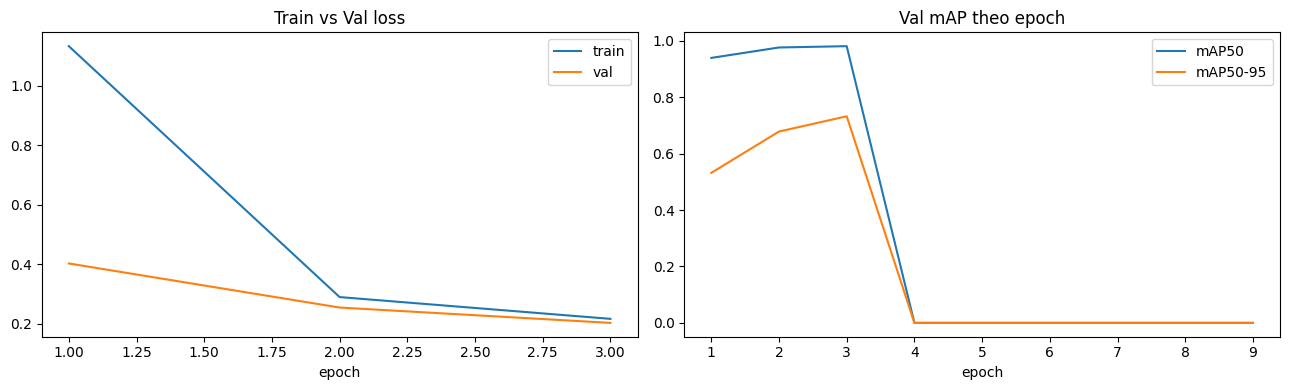

Epoch tốt nhất: 3 | val_mAP50 = 0.9809


In [ ]:
import pandas as pd, matplotlib.pyplot as plt
hist = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hist['epoch'], hist['train_loss'], label='train'); ax[0].plot(hist['epoch'], hist['val_loss'], label='val')
ax[0].set_title('Train vs Val loss'); ax[0].legend(); ax[0].set_xlabel('epoch')
ax[1].plot(hist['epoch'], hist['val_mAP50'], label='mAP50'); ax[1].plot(hist['epoch'], hist['val_mAP50_95'], label='mAP50-95')
ax[1].set_title('Val mAP theo epoch'); ax[1].legend(); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.savefig(os.path.join(CHECKPOINT_DIR,'learning_curves.png'), dpi=120); plt.show()
best_epoch = int(hist.loc[hist['val_mAP50'].idxmax(),'epoch'])
print("Epoch tốt nhất:", best_epoch, "| val_mAP50 =", round(hist['val_mAP50'].max(),4))


## 9. Đánh giá CUỐI trên tập TEST (19.200 ảnh) bằng best.pth

In [ ]:
model.load_state_dict(torch.load(CKPT_BEST, map_location=device)['model'])
print("Đã nạp best.pth. Đang chấm trên tập test...")
stats = evaluate_coco(model, test_loader, test_ds.coco)
map50_95=float(stats[0]); map50=float(stats[1]); map75=float(stats[2])
ap_s=float(stats[3]); ap_m=float(stats[4]); ap_l=float(stats[5])
ar100=float(stats[8]); ar_s=float(stats[9]); ar_m=float(stats[10]); ar_l=float(stats[11])
prf = compute_pr_f1(model, test_loader)
print("PR/F1:", prf)
print(f"AP small {ap_s:.4f} | AR small {ar_s:.4f}")


Đã nạp best.pth. Đang chấm trên tập test...
Loading and preparing results...
DONE (t=3.54s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=238.24s).
Accumulating evaluation results...
DONE (t=11.46s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.736
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.981
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.868
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.736
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.071
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.600
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.789
 Average Recall     

## 10. Đo FPS (GPU) & lưu kết quả theo schema chung

In [ ]:
def measure_fps(model, ds, n=100, warm=10):
    model.eval(); ts=[]
    with torch.no_grad():
        for i in range(min(n+warm, len(ds))):
            im,_ = ds[i]; im = im.to(device)
            if device.type=='cuda': torch.cuda.synchronize()
            s=time.time(); _=model([im])
            if device.type=='cuda': torch.cuda.synchronize()
            if i>=warm: ts.append(time.time()-s)
    avg=sum(ts)/len(ts); return 1.0/avg, avg*1000

fps, inf_ms = measure_fps(model, test_ds)
n_params = sum(p.numel() for p in model.parameters())
print(f"FPS {fps:.2f} | {inf_ms:.2f} ms/anh | params {n_params/1e6:.2f}M")

def save_result(name, d, path=RESULTS_JSON):
    allr = json.load(open(path)) if os.path.exists(path) else {}
    allr[name] = d
    json.dump(allr, open(path,'w'), indent=2, ensure_ascii=False)
    print("Da luu:", name)

save_result('RetinaNet', {
    'mAP50': map50, 'mAP50_95': map50_95, 'mAP75': map75,
    'AP_small': ap_s, 'AP_medium': ap_m, 'AP_large': ap_l,
    'AR_max100': ar100, 'AR_small': ar_s, 'AR_medium': ar_m, 'AR_large': ar_l,
    'precision': prf['precision'], 'recall': prf['recall'], 'f1_score': prf['f1'],
    'TP': prf['TP'], 'FP': prf['FP'], 'FN': prf['FN'],
    'best_epoch': best_epoch, 'total_epochs_run': int(hist['epoch'].max()),
    'fps': fps, 'inference_ms': inf_ms,
    'n_params': int(n_params), 'n_params_millions': round(n_params/1e6, 2),
    'total_train_time_min': round(total_train_time/60, 2),
    'peak_gpu_mem_gb': round(peak_mem, 2) if peak_mem else None,
    'eval_split': 'test (19200 anh)',
})


FPS 39.33 | 25.43 ms/anh | params 32.17M
Da luu: RetinaNet
